<a href="https://colab.research.google.com/github/jarizmendi18-source/Actividad5/blob/main/Actividad5%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import os

for raiz, carpetas, archivos in os.walk("/content/drive/MyDrive/Actividad 5/fuentes"):
    if "datos_prep.py" in archivos:
        print(os.path.join(raiz, "datos_prep.py"))

/content/drive/MyDrive/Actividad 5/fuentes/datos_prep.py


In [ ]:
!pip install mlflow

In [ ]:
import mlflow

print(mlflow.__version__)

3.14.0


In [ ]:
import mlflow
import mlflow.sklearn

In [ ]:
from datos_prep import cargar_dataset

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

import mlflow
import mlflow.sklearn

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X,y=cargar_dataset("/content/drive/MyDrive/Actividad 5/Datos/datos_ini")

In [ ]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")

mlflow.set_experiment("Clasificacion_Prendas")

2026/06/25 03:45:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/25 03:45:26 INFO mlflow.store.db.utils: Updating database tables
2026/06/25 03:45:29 INFO mlflow.tracking.fluent: Experiment with name 'Clasificacion_Prendas' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1782359129482, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782359129482, lifecycle_stage='active', name='Clasificacion_Prendas', tags={}, trace_location=None, workspace='default'>

In [ ]:
print(mlflow.get_tracking_uri())

sqlite:///mlflow.db


In [ ]:
param_grid = {
    "C":[0.1,1,10]
}

In [ ]:
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5
)

In [ ]:
grid_lr.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.1, 1, 10]})

In [ ]:
grid_lr.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.1, 1, 10]})

In [ ]:
y_pred = grid_lr.predict(X_test)

In [ ]:
acc = accuracy_score(y_test,y_pred)

prec = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

rec = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

In [ ]:
with mlflow.start_run(run_name="LogisticRegression"):

    mlflow.log_param(
        "C",
        grid_lr.best_params_["C"]
    )

    mlflow.log_metric("accuracy",acc)
    mlflow.log_metric("precision",prec)
    mlflow.log_metric("recall",rec)
    mlflow.log_metric("f1",f1)

    mlflow.sklearn.log_model(
        grid_lr.best_estimator_,
        "modelo"
    )

2026/06/25 04:00:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
param_grid = {

    "n_estimators":[50,100],

    "max_depth":[5,10]
}

In [ ]:
grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5
)

In [ ]:
grid_rf.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10], 'n_estimators': [50, 100]})

In [ ]:
y_pred = grid_rf.predict(X_test)

In [ ]:
acc = accuracy_score(y_test,y_pred)

prec = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

rec = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

In [ ]:
with mlflow.start_run(run_name="RandomForest"):

    mlflow.log_param(
        "n_estimators",
        grid_rf.best_params_["n_estimators"]
    )

    mlflow.log_param(
        "max_depth",
        grid_rf.best_params_["max_depth"]
    )

    mlflow.log_metric("accuracy",acc)
    mlflow.log_metric("precision",prec)
    mlflow.log_metric("recall",rec)
    mlflow.log_metric("f1",f1)

    mlflow.sklearn.log_model(
        grid_rf.best_estimator_,
        "modelo"
    )

2026/06/25 04:06:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
scores = cross_val_score(
    grid_rf.best_estimator_,
    X,
    y,
    cv=kf
)

In [ ]:
mlflow.log_metric(
    "cv_accuracy",
    scores.mean()
)

In [ ]:
import sys
print("google.colab" in sys.modules)

True


In [ ]:
experiment = mlflow.get_experiment_by_name("Clasificacion_Prendas")

print(experiment)

<Experiment: artifact_location='/content/mlruns/1', creation_time=1782359129482, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782359129482, lifecycle_stage='active', name='Clasificacion_Prendas', tags={}, trace_location=None, workspace='default'>


In [ ]:
runs = mlflow.search_runs()

runs[[
    "run_id",
    "metrics.accuracy",
    "metrics.precision",
    "metrics.recall",
    "metrics.f1"
]]

,run_id,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1
0,183e97ea6d46416b8cc940f3ad0afc35,NaN,NaN,NaN,NaN
1,bbe97bfcd07444cb8cdafc6a737e1ae6,0.823333,0.824447,0.823333,0.823762
2,7a0189b1c9cc47c58cf2d841f312559b,0.743333,0.749341,0.743333,0.744610


In [ ]:
!pip install pyngrok

In [ ]:
runs = mlflow.search_runs()

runs[[
    "tags.mlflow.runName",
    "metrics.accuracy",
    "metrics.precision",
    "metrics.recall",
    "metrics.f1"
]]

,tags.mlflow.runName,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1
0,unruly-stag-676,NaN,NaN,NaN,NaN
1,RandomForest,0.823333,0.824447,0.823333,0.823762
2,LogisticRegression,0.743333,0.749341,0.743333,0.744610


In [ ]:
!ngrok config add-authtoken 3Fc65ui0NoQHIyykJ9nenRGmyRc_87B72sxb1NTFrW5W2DFTc

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3Fc65ui0NoQHIyykJ9nenRGmyRc_87B72sxb1NTFrW5W2DFTc")

In [ ]:
public_url = ngrok.connect(5000)
print(public_url)

NgrokTunnel: "https://neuron-wavy-anteater.ngrok-free.dev" -> "http://localhost:5000"


In [ ]:
runs = mlflow.search_runs()

runs.to_csv("resultados_mlflow.csv", index=False)

In [ ]:
from google.colab import files

files.download("resultados_mlflow.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import mlflow

runs = mlflow.search_runs()
runs.to_csv("resultados.csv", index=False)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[87  9  8]
 [10 66  9]
 [ 4 13 94]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       104
           1       0.75      0.78      0.76        85
           2       0.85      0.85      0.85       111

    accuracy                           0.82       300
   macro avg       0.82      0.82      0.82       300
weighted avg       0.82      0.82      0.82       300



In [ ]:
results = {}
results["LogReg"] = {"acc": acc_lr, "f1": f1_lr}
results["RF"] = {"acc": acc_rf, "f1": f1_rf}

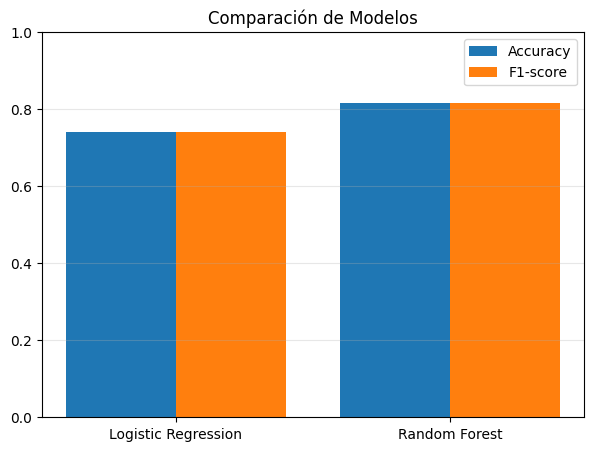

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

modelos = ["Logistic Regression", "Random Forest"]

accuracy = [acc_lr, acc_rf]
f1 = [f1_lr, f1_rf]

x = np.arange(len(modelos))

plt.figure(figsize=(7,5))

plt.bar(x - 0.2, accuracy, 0.4, label="Accuracy")
plt.bar(x + 0.2, f1, 0.4, label="F1-score")

plt.xticks(x, modelos)
plt.ylim(0, 1)
plt.title("Comparación de Modelos")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

<Figure size 600x600 with 0 Axes>

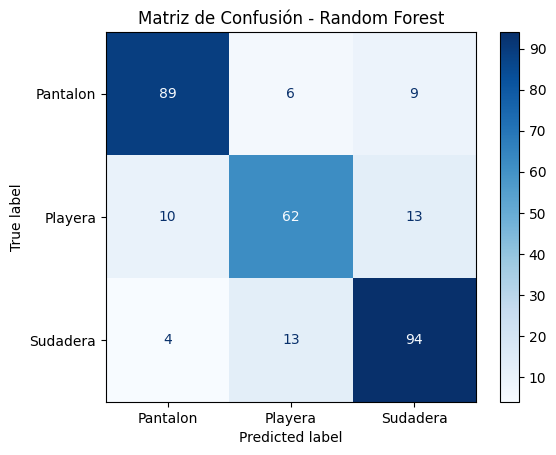

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,6))

disp = ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    display_labels=["Pantalon", "Playera", "Sudadera"],
    cmap="Blues"
)

plt.title("Matriz de Confusión - Random Forest")
plt.show()

<Figure size 600x600 with 0 Axes>

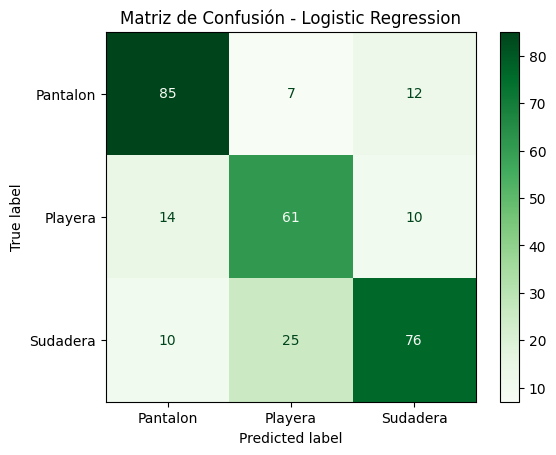

In [64]:
plt.figure(figsize=(6,6))

disp = ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    display_labels=["Pantalon", "Playera", "Sudadera"],
    cmap="Greens"
)

plt.title("Matriz de Confusión - Logistic Regression")
plt.show()

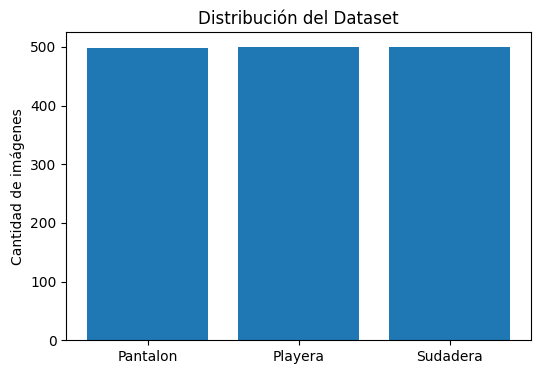

In [ ]:
import numpy as np

labels = ["Pantalon", "Playera", "Sudadera"]
counts = [np.sum(y == 0), np.sum(y == 1), np.sum(y == 2)]

plt.figure(figsize=(6,4))

plt.bar(labels, counts)
plt.title("Distribución del Dataset")
plt.ylabel("Cantidad de imágenes")

plt.show()